In [ ]:
#multi object
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow

from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


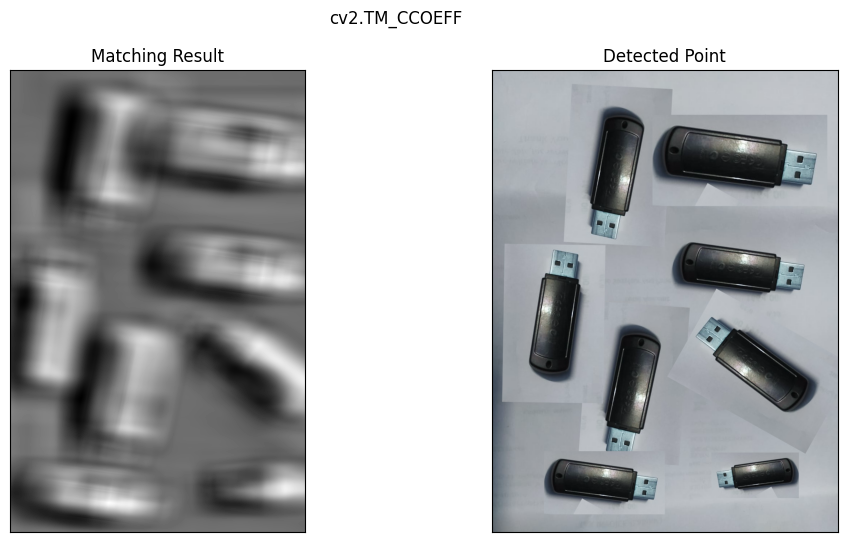

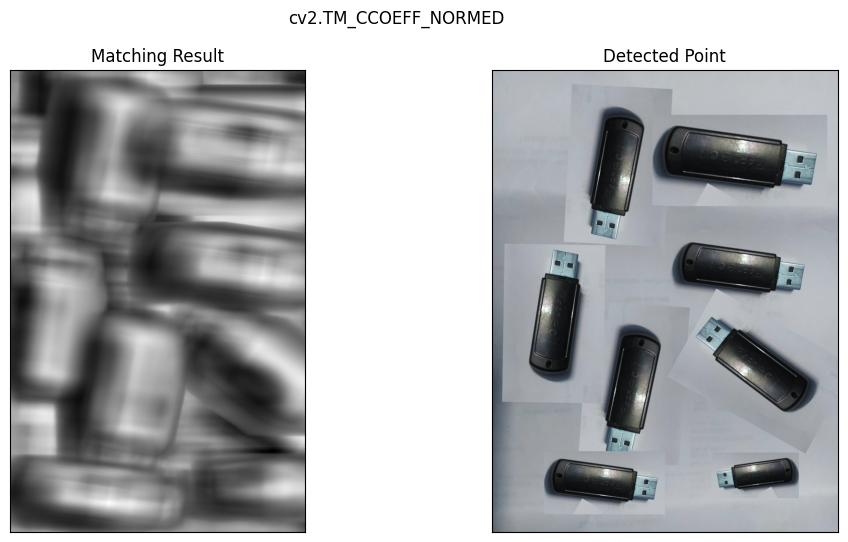

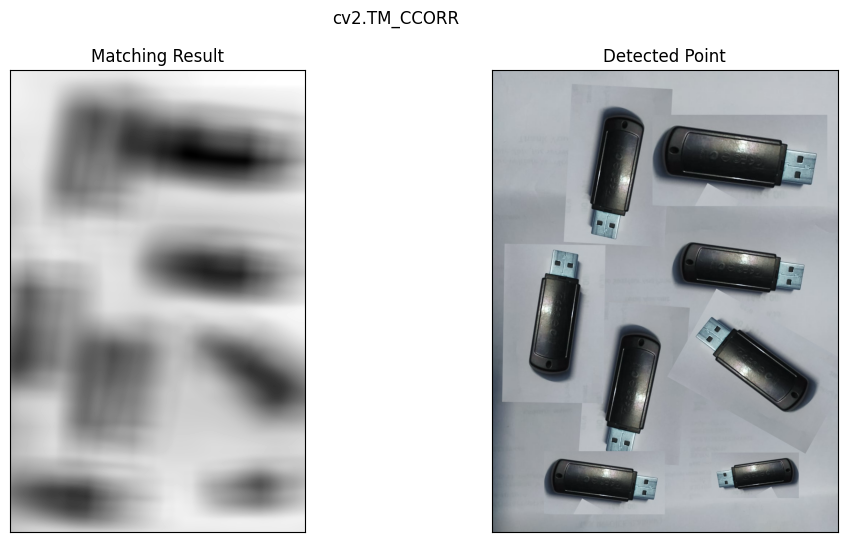

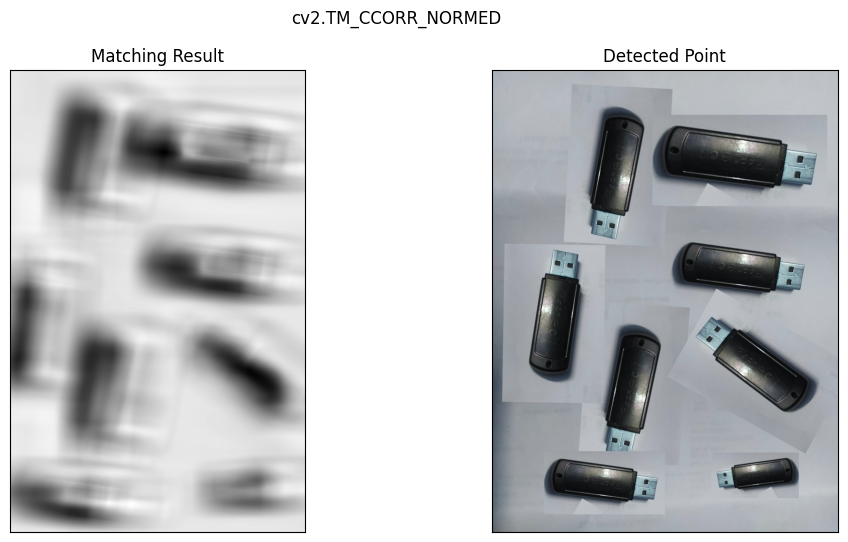

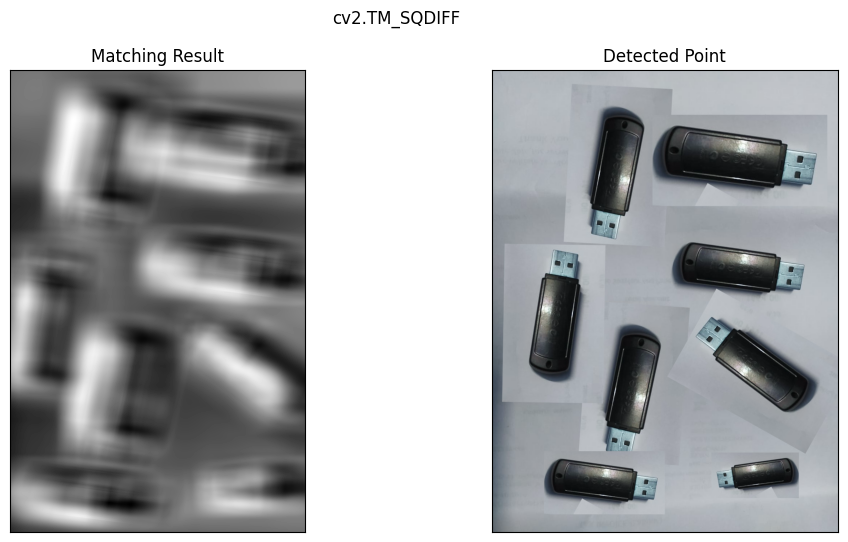

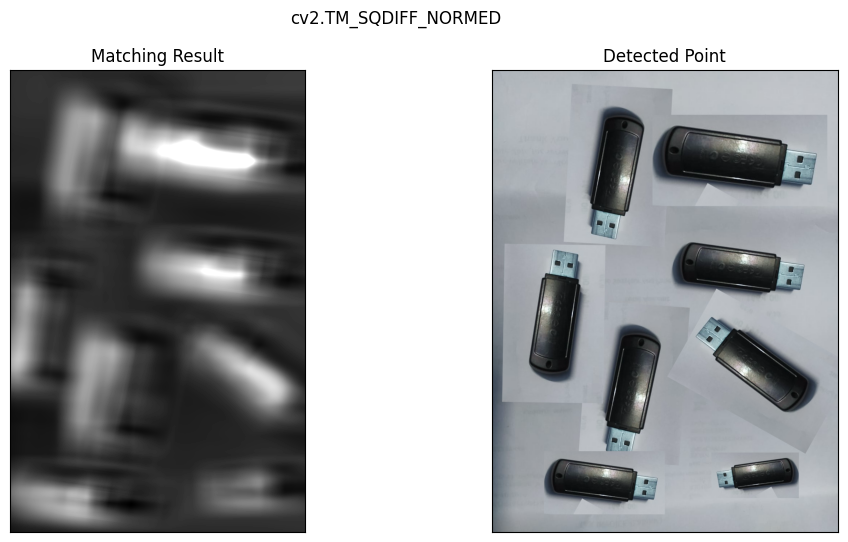

In [ ]:

img_rgb = cv2.imread('/content/gdrive/MyDrive/arwaa img/usb1.jpg',)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2GRAY)
template = cv2.imread('/content/gdrive/MyDrive/arwaa img/usb2.jpg', 0)
w, h = template.shape[::-1]

res = cv2.matchTemplate(img_gray, template, cv2.TM_CCOEFF_NORMED)
threshold = 0.8
loc = np.where(res >= threshold)
methods = ['cv2.TM_CCOEFF', 'cv2.TM_CCOEFF_NORMED', 'cv2.TM_CCORR',
            'cv2.TM_CCORR_NORMED', 'cv2.TM_SQDIFF', 'cv2.TM_SQDIFF_NORMED']

img_result = img_rgb.copy()

for meth in methods:
    img = img_rgb.copy()
    method = eval(meth)
    res = cv2.matchTemplate(img_gray, template, method)

    for pt in zip(*loc[::-1]):
        cv2.rectangle(img_result, pt, (pt[0] + w, pt[1] + h), (0, 0, 255), 2)

    plt.figure(figsize=(12, 6))
    plt.subplot(121), plt.imshow(res, cmap='gray')
    plt.title('Matching Result'), plt.xticks([]), plt.yticks([])
    plt.subplot(122), plt.imshow(img_result, cmap='gray')
    plt.title('Detected Point'), plt.xticks([]), plt.yticks([])
    plt.suptitle(meth)
    plt.show()
